# Noise reduction

The goal of this notebook is to reduce noise amongst all data files using a noise reduction library and plot the results.
The setup is this:
1. Go through all sound files in `./data`
2. Load the raw signal
3. Load part of the raw signal a noise reference data
4. Reduce noise through use of a library
5. Generate spectogram for resulting waveform
6. Store spectogram and noise-reduced audio in `./wave_forms_denoised` and `./data_denoised` respectively

First, let's import all the necessary libraries:

In [ ]:
import soundfile as sf          # Loads audio files from memory
import noisereduce as nr        # Can reduce noise in audio buffers
import numpy as np              # Needed for audio compression
import os                       # OS interface
import matplotlib.pyplot as plt # Plots denoised audio files

/home/arian/Documents/Master/03-IMAA-IMS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We will declare some constants and get a list of all data files:

In [4]:
DATA_DIR = "./data"
DENOISED_WAVE_FORM_DIR = "./wave_forms_denoised"
DENOISED_DIR = "./data_denoised"
wav_file_paths = sorted(os.listdir(DATA_DIR))

This function loads in unfiltered data from our `.wav`-files:

In [5]:
def get_signal(path: str) -> np.ndarray:
    signal, sample_rate = sf.read(f"{DATA_DIR}/{path}")
    return signal, sample_rate

This is where the magic happens.

- Used `get_signal()` to load the data
- Naively assume first 10% of data is always noise
- Use "noisereduce" library to reduce noise
    - 99% reduction rate (`prop_decrease`)
    - Assume noise is unchanged within one file (`stationary`)
    - Relatively lenient noise reduction (`n_std_thresh_stationary`)
- Smooth out noise to remove unpleasant peaks (`np.tanh`) (since we have a lot of silence and SUPER loud parts i.e. when the hydrophone is being moved)
- Return amplified + denoised signal

In [ ]:
def get_denoised_signal(path: str, amp: int = 5):
    noise_reference_signal, sample_rate = get_signal(path)
    noise_lim = int(len(noise_reference_signal)/10)
    noise_sample = noise_reference_signal[:noise_lim]

    audio_data, _ = get_signal(path)

    reduced_noise_audio = nr.reduce_noise(y=audio_data, sr=sample_rate, y_noise=noise_sample, prop_decrease=0.999, stationary=True, n_std_thresh_stationary=4.0)

    compressed_audio = np.tanh(reduced_noise_audio * 1.5)
    max_peak = np.max(np.abs(compressed_audio))
    if max_peak > 0:
        reduced_noise_audio = (compressed_audio / max_peak) * 1.0

    return reduced_noise_audio * amp, sample_rate

'\nfig,axs = plt.subplots(2)\naxs[0].specgram(audio_data)\naxs[1].specgram(reduced_noise_audio)\nplt.tight_layout()\nplt.show()\n'

Finally, go through all files, denoise them and store both the waveform spectrogram and raw in their respective folders (may take some time to run):

Skipping 0
Skipping 1
Skipping 2
Skipping 3
Skipping 4
Skipping 5
Skipping 6
Skipping 7
Skipping 8
Skipping 9
Skipping 10
Skipping 11
Skipping 12
Skipping 13
Skipping 14
Skipping 15
Skipping 16
Skipping 17
Skipping 18
Skipping 19
Skipping 20
Skipping 21
Skipping 22
Skipping 23
Skipping 24
Skipping 25
Skipping 26
Generating wave file: 130000 #27/40
Generating wave file: 131000 #28/40
Generating wave file: 132000 #29/40
Generating wave file: 133000 #30/40
Generating wave file: 134000 #31/40
Generating wave file: 135000 #32/40
Generating wave file: 140000 #33/40
Generating wave file: 141000 #34/40
Generating wave file: 142000 #35/40
Generating wave file: 143000 #36/40
Generating wave file: 144000 #37/40
Generating wave file: 145000 #38/40
Generating wave file: 150000 #39/40


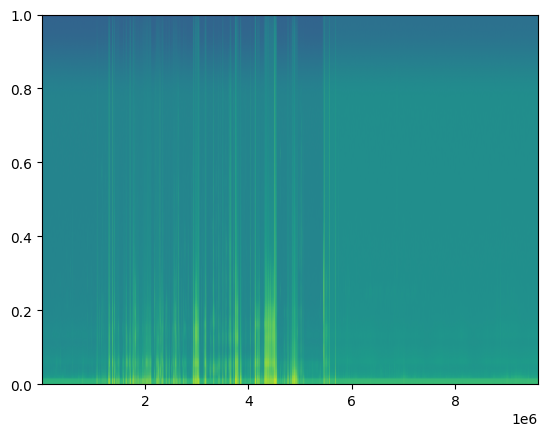

In [ ]:
for i, wav_file_path in enumerate(wav_file_paths):
    time_stamp = wav_file_path.split("_")[-1].split(".")[0]
    # Since the process takes so long we want to be able to pick it up where we left of last time
    if os.path.exists(f"{DENOISED_WAVE_FORM_DIR}/{time_stamp}.png"):
        print(f"Skipping {i}")
        continue
    print(f"Generating wave file: {time_stamp} #{i}/{len(wav_file_paths)}")
    signal, sample_rate = get_denoised_signal(wav_file_path)
    plt.specgram(signal)
    plt.savefig(f"{DENOISED_WAVE_FORM_DIR}/{time_stamp}.png")
    sf.write(f"{DENOISED_DIR}/{time_stamp}.wav", signal, sample_rate)